# FIT5196 Assessment 1 - EDA

---



#### Group64:
Member 1: Hao Xie (32613571), hxie0035@student.monash.edu, Insights

Member 2: Yilin Shen, (34754954), yshe0132@student.monash.edu, EDA Visualization

Member 3: Tianyang Huang, (35310464), thua0061@student.monash.edu, EDA Design

Member 4: Vincent Ha (32518714), vhaa0001@student.monash.edu, Machine Learning Questions

---

### Table of Content

1. Load, parse and merge data files
2. EDA
3. Key insights 
1. Machine Learning Questions and Justifications
2. References





# 1. Load, parse and merge data files

In [1]:
# Import all the modules
import json
import re

import pandas as pd
import numpy as np

1. Load and Parse the XML file

In [2]:
# pd.read_xmlparses the xml into dataframe directly
df_xml = pd.read_xml('group_64.xml', encoding='utf-8')
print("XML shape:", df_xml.shape)
print(df_xml.columns.tolist())

XML shape: (14720, 18)
['PostID', 'UserID', 'secret', 'server', 'title', 'ispublic', 'isfriend', 'isfamily', 'farm', 'City', 'Country', 'Post_date', 'Taken_date', 'tags', 'latitude', 'longitude', 'description', 'min_taken_date']


2. Load and Parse the JSON File

In [3]:
# json.load() reads the file into a Python list of dicts; pd.DataFrame converts it
with open('group_64.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df_json = pd.DataFrame(data)
print("JSON shape:", df_json.shape)
print(df_json.head())

JSON shape: (29440, 18)
         PostID        UserID      secret   server  \
0  4.931549e+10  95897158@N02  1cb85fc603  65535.0   
1  4.931618e+10  16057556@N07  e49e95d2cb  65535.0   
2  4.931592e+10  39414578@N03  805b4e01fb  65535.0   
3  4.931592e+10  39414578@N03  8618800c33  65535.0   
4  4.931613e+10  39414578@N03  2bcce66ae7  65535.0   

                                               title  ispublic  isfriend  \
0      Een damesfiets opgeknapt voor mijn oude dag .       1.0       0.0   
1  TC-LJA - 2015 build Boeing B777-3F2ER, inbound...       1.0       0.0   
2                                 New Years Day Dip.       1.0       0.0   
3                                 New Years Day Dip.       1.0       0.0   
4                                 New Years Day Dip.       1.0       0.0   

   isfamily  farm  City Country            Post date           Taken date  \
0       0.0  66.0  None    None  2020-01-02 13:58:04  2020-01-02 00:12:05   
1       0.0  66.0  None    None  2020-01

3. Schema Alignment - Rename Columns and Enforce Data Types

In [4]:
# Rename JSON columns so they match the XML naming convention (underscores)
df_json = df_json.rename(columns = {
    'Post date': 'Post_date',
    'Taken date': 'Taken_date'
})
dtype_mapping = {
    'PostID': 'Int64',
    'UserID': 'string',
    'secret': 'string',
    'server': 'Int64',
    'title': 'string',
    'ispublic': 'Int64',
    'isfriend': 'Int64',
    'isfamily': 'Int64',
    'farm': 'Int64',
    'City': 'string',
    'Country': 'string',
    'tags': 'string',
    'description': 'string'
}
# Apply type casting to both DataFrames
datetime_cols = ['Post_date', 'Taken_date', 'min_taken_date']
# Convert date coulmns to proper datetime objects
df_json = df_json.astype(dtype_mapping)
df_xml = df_xml.astype(dtype_mapping)
for col in datetime_cols:
    df_json[col] = pd.to_datetime(df_json[col])
    df_xml[col] = pd.to_datetime(df_xml[col])

4. Merge (Concatenate) the Two Datasets

In [5]:

# Merge (Concatenate) the Two Datasets
df_merged = pd.concat([df_xml, df_json], ignore_index = True)
print(df_merged.shape)

(44160, 18)


5. Duplication

In [6]:

# 5a. Remove duplicate rows across all columns
df_merged = df_merged.drop_duplicates()
print(df_merged.shape)



(29565, 18)


In [7]:
# Inspect remaining PostID-level duplicates
dup_count = df_merged['PostID'].duplicated().sum()
print(dup_count)


29


Result show 29 duplicate rows remaining after drop duplicates

In [8]:
# Investigation: duplicates differ only in min_taken_date
duplicates = df_merged[df_merged['PostID'].duplicated(keep=False)]
sample_id = duplicates['PostID'].iloc[0]
print(df_merged[df_merged['PostID'] == sample_id])

           PostID        UserID      secret  server  \
80    49384552911  60505704@N04  17b58f9425   65535   
3546  49384552911  60505704@N04  17b58f9425   65535   

                                                  title  ispublic  isfriend  \
80    Tyrers Coaches, Adlington YN57FYV at Farnworth...         1         0   
3546  Tyrers Coaches, Adlington YN57FYV at Farnworth...         1         0   

      isfamily  farm  City Country           Post_date          Taken_date  \
80           0    66  <NA>    <NA> 2020-01-14 13:32:49 2020-01-13 08:08:48   
3546         0    66  <NA>    <NA> 2020-01-14 13:32:49 2020-01-13 08:08:48   

                                                   tags   latitude  longitude  \
80    scaniak230ub,tyrerscoaches,adlington,farnworth...  53.548904  -2.394311   
3546  scaniak230ub,tyrerscoaches,adlington,farnworth...  53.548904  -2.394311   

                                   description min_taken_date  
80    New to Nottingham City Transport as 304.     20

Output shows the two identical rows only differs in min_taken_date, we can resolve by keeping the record with the earliest min_taken_date

In [9]:
df_merged = df_merged.sort_values('min_taken_date', ascending=True)
df_merged = df_merged.drop_duplicates(subset=['PostID'], keep='first')
df_merged = df_merged.reset_index(drop=True)
print(df_merged.shape)



(29536, 18)


Verify: no remaining PostID duplicates

In [10]:
assert df_merged['PostID'].duplicated().sum() == 0, "PostID duplicates still exist!"

6. Text Cleaning (Regular Expressions - applied only to text columns)

In [11]:
# Define the target text columns (as required by the spec)
text_cols = ['title', 'City', 'Country', 'tags', 'description']


Define  regex patterns for efficiency (compiled first and reuse it later)

In [12]:
# XML/HTML pattern: Marches tags like <br>, <p class="x", </div>, dtc.
RE_HTML_TAGS = re.compile(r'<[^>]+>')

In [13]:
# Match emojis, pictographs, zero-width joiners, and variation selectors.
RE_EMOJI = re.compile(
    '['
    '\U0001F600-\U0001F64F'   # Emoticons (smileys, gestures)
    '\U0001F300-\U0001F5FF'   # Miscellaneous Symbols and Pictographs
    '\U0001F680-\U0001F6FF'   # Transport and Map Symbols
    '\U0001F1E0-\U0001F1FF'   # Regional Indicator Symbols (flags)
    '\U0001F900-\U0001F9FF'   # Supplemental Symbols and Pictographs
    '\U0001FA00-\U0001FA6F'   # Chess Symbols
    '\U0001FA70-\U0001FAFF'   # Symbols and Pictographs Extended-A
    '\U00002702-\U000027B0'   # Dingbats
    '\U00002600-\U000026FF'   # Miscellaneous Symbols
    '\U0000FE00-\U0000FE0F'   # Variation Selectors
    '\U0000200D'              # Zero Width Joiner
    '\U00002300-\U000023FF'   # Miscellaneous Technical (some emoji)
    '\U0000200C-\U0000200D'   # Zero Width Non-Joiner + Joiner
    '\U000000A9'              # Copyright symbol (sometimes rendered as emoji)
    '\U000000AE'              # Registered symbol
    '\U0000203C'              # Double exclamation mark
    '\U00002049'              # Exclamation question mark
    '\U000020E3'              # Combining Enclosing Keycap
    '\U00002122'              # Trade mark sign
    '\U00002139'              # Information source
    '\U00002194-\U000021AA'   # Arrows (sometimes emoji)
    '\U000025AA-\U000025AB'   # Small squares
    '\U000025B6'              # Play button
    '\U000025C0'              # Reverse button
    '\U000025FB-\U000025FE'   # Medium squares
    '\U00003030'              # Wavy dash
    '\U0000303D'              # Part alternation mark
    '\U00003297'              # Circled ideograph congratulation
    '\U00003299'              # Circled ideograph secret
    ']+',
    flags=re.UNICODE
)

In [14]:
# non-Latin script Pattern
# Allowed: Latin script (Basic Latin, Latin-1 Supplement, Latin Extended-A/B,
#          Latin Extended Additional), combining diacritical marks,
#          digits, whitespace, ASCII punctuation, common Unicode punctuation, and @.

RE_NON_LATIN = re.compile(
    r'[^'
    r'a-zA-Z'                 # Basic Latin letters
    r'\u00C0-\u00D6'          # Latin-1 Supplement (upper accented: A-grave to O-diaeresis)
    r'\u00D8-\u00F6'          # Latin-1 Supplement (O-stroke to o-diaeresis)
    r'\u00F8-\u00FF'          # Latin-1 Supplement (o-stroke to y-diaeresis)
    r'\u0100-\u017F'          # Latin Extended-A (e.g., macrons, carons)
    r'\u0180-\u024F'          # Latin Extended-B (e.g., Croatian, Romanian digraphs)
    r'\u1E00-\u1EFF'          # Latin Extended Additional (e.g., Vietnamese)
    r'\u0300-\u036F'          # Combining Diacritical Marks (accents, tildes, etc.)
    r'\s'                     # Whitespace (space, tab, newline)
    r'0-9'                    # Digits
    r'!"#$%&\'()*+,\-./:;<=>?@\[\\\]^_`{|}~'   # ASCII punctuation
    r'\u2010-\u2027'          # General Punctuation (en-dash, em-dash, quotes, etc.)
    r'\u2030-\u205E'          # Per-mille, prime, brackets, etc.
    r']'
)

In [15]:
def clean_text(text):
    """
    Clean a single text value by sequentially removing:
      1. XML/HTML tags (e.g., <br>, <a href="...">)
      2. Emojis and pictographic symbols
      3. Non-Latin characters (Japanese, Chinese, Russian Cyrillic, etc.)
    Retains: Latin script (including European diacritics), digits, whitespace,
             punctuation, and the @ symbol.
    Returns the original value unchanged if it is not a string (e.g., NaN).
    """
    if not isinstance(text, str):
        return text
    # Step 1: Remove XML/HTML tags
    text = RE_HTML_TAGS.sub('', text)
    # Step 2: Remove emojis and associated joiners / variation selectors
    text = RE_EMOJI.sub('', text)
    # Step 3: Remove non-Latin characters
    text = RE_NON_LATIN.sub('', text)
    return text

# Apply cleaning to all string/object columns
string_cols = df_merged.select_dtypes(include=['string', 'object']).columns.tolist()
for col in string_cols:
    df_merged[col] = df_merged[col].map(clean_text)

7. Lowercase Transformation

In [16]:
# .str.lower() automatically preserves NaN values
df_merged[text_cols] = df_merged[text_cols].apply(lambda x: x.str.lower())
print(df_merged[text_cols].head(10))

                                              title               City  \
0                         welcome to the new decade            glasgow   
1                               new year's day swim               <NA>   
2             collieston harbour - 1st january 2020               <NA>   
3                                      old graffiti           grantham   
4  day breaking over aberdeen lighthoose 02/01/2020  aberdeen/scotland   
5                           trentham fairy - wishes     stoke on trent   
6                                              <NA>               <NA>   
7                                              <NA>               <NA>   
8                 n182 lap - 1995 alfa romeo 155 v6    buckinghamshire   
9    jda 74 - 1950 reliant girder fork tricycle van    buckinghamshire   

          Country                                               tags  \
0  united kingdom              glasgow,scotland,uk,2020,newyearsday,   
1         ireland  frankfullard,fullard,c

8. Date Formatting - Standardise min_taken_date Display

In [17]:
# Standardise min_taken_date to a consistent string for output
df_merged['min_taken_date'] = (
    pd.to_datetime(df_merged['min_taken_date'])
    .dt.strftime('%Y-%m-%d %H:%M:%S')
)
# Convert min_taken_date back to datetime type
df_merged['min_taken_date'] = pd.to_datetime(df_merged['min_taken_date'])
print(df_merged['min_taken_date'])
print(df_merged.dtypes)

0       2020-01-01
1       2020-01-01
2       2020-01-01
3       2020-01-01
4       2020-01-01
           ...    
29531   2020-01-16
29532   2020-01-16
29533   2020-01-16
29534   2020-01-16
29535   2020-01-16
Name: min_taken_date, Length: 29536, dtype: datetime64[ns]
PostID                     Int64
UserID                    object
secret                    object
server                     Int64
title                     object
ispublic                   Int64
isfriend                   Int64
isfamily                   Int64
farm                       Int64
City                      object
Country                   object
Post_date         datetime64[ns]
Taken_date        datetime64[ns]
tags                      object
latitude                 float64
longitude                float64
description               object
min_taken_date    datetime64[ns]
dtype: object


9. Null Value Handling

In [18]:
# Replace empty strings and whitespace-only strings with NaN
df_merged = df_merged.replace(r'^\s*$', np.nan, regex=True)

In [19]:
# Replace common null-like strings with NaN
null_like_values = ['none', 'null', 'na', 'n/a', 'None', 'NULL', 'NA', 'N/A', '']
df_merged = df_merged.replace(null_like_values, np.nan)
print(df_merged.isna().sum())

PostID                1
UserID                1
secret                1
server                1
title               865
ispublic              1
isfriend              1
isfamily              1
farm                  1
City              16144
Country           16342
Post_date             0
Taken_date            1
tags              10192
latitude              1
longitude             1
description       12657
min_taken_date        0
dtype: int64


10. Validation Checks (tageted to text columns)

In [20]:
# 10a. Check for remaining XML/HTML tags
def has_html_tags(text):
    if not isinstance(text, str):
        return False
    return bool(RE_HTML_TAGS.search(text))

In [21]:
html_counts = df_merged[string_cols].apply(lambda col: col.map(has_html_tags)).sum()
print("XML/HTML tags remaining:")
print(html_counts)
assert html_counts.sum() == 0, "XML/HTML tags still present!"

XML/HTML tags remaining:
UserID         0
secret         0
title          0
City           0
Country        0
tags           0
description    0
dtype: int64


In [22]:
# 10b. Check for remaining non-Latin characters
def has_non_latin(text):
    if not isinstance(text, str):
        return False
    return bool(RE_NON_LATIN.search(text))

non_latin_counts = df_merged[string_cols].apply(lambda col: col.map(has_non_latin)).sum()
print("Non-Latin characters remaining:")
print(non_latin_counts)
assert non_latin_counts.sum() == 0, "Non-Latin characters still present!"

Non-Latin characters remaining:
UserID         0
secret         0
title          0
City           0
Country        0
tags           0
description    0
dtype: int64


In [23]:
# 10c. Check for remaining emojis
def has_emoji(text):
    if not isinstance(text, str):
        return False
    return bool(RE_EMOJI.search(text))

emoji_counts = df_merged[string_cols].apply(lambda col: col.map(has_emoji)).sum()
print(f"Emoji characters remaining:\n{emoji_counts}")
assert emoji_counts.sum() == 0, "Emoji characters still present!"

Emoji characters remaining:
UserID         0
secret         0
title          0
City           0
Country        0
tags           0
description    0
dtype: int64


In [24]:
# 10d. Check no null-like string literals remain
null_like_check = ['None', 'none', 'NULL', 'null', 'NA', 'na',
                   'N/A', 'n/a', 'nan', 'NaN', '']
for col in df_merged.columns:
    matches = df_merged[col].isin(null_like_check).sum()
    if matches > 0:
        print(f"  Warning: Column '{col}' has {matches} null-like strings remaining")

In [25]:
# Convert the min_taken_date back to string format, as it needs to display 00:00:00
df_merged['min_taken_date'] = pd.to_datetime(df_merged['min_taken_date']).dt.strftime('%Y-%m-%d %H:%M:%S')
# 10e. Confirm date columns are not corrupted
print(df_merged[['Post_date', 'Taken_date', 'min_taken_date']].head(10).to_string())


            Post_date          Taken_date       min_taken_date
0 2020-01-01 11:11:15 2020-01-01 08:30:21  2020-01-01 00:00:00
1 2020-01-02 06:03:31 2020-01-01 13:53:33  2020-01-01 00:00:00
2 2020-01-02 17:48:19 2020-01-01 14:34:42  2020-01-01 00:00:00
3 2020-01-02 17:41:03 2020-01-02 12:41:41  2020-01-01 00:00:00
4 2020-01-02 17:03:09 2020-01-02 07:50:42  2020-01-01 00:00:00
5 2020-01-02 16:36:36 2020-01-01 14:43:42  2020-01-01 00:00:00
6 2020-01-02 16:20:59 2020-01-01 11:01:33  2020-01-01 00:00:00
7 2020-01-02 16:20:59 2020-01-01 11:16:28  2020-01-01 00:00:00
8 2020-01-02 15:56:17 2020-01-01 11:50:33  2020-01-01 00:00:00
9 2020-01-02 15:23:35 2020-01-01 11:33:17  2020-01-01 00:00:00


11. Rename columns to match sample output format

In [26]:

# The sample output file specifies exact column names with underscores and
# title-case formatting. Renaming to match exactly.
column_rename_map = {
    'PostID':         'Post_ID',
    'UserID':         'User_ID',
    'secret':         'Secret',
    'server':         'Server',
    'title':          'Title',
    'ispublic':       'Is_Public',
    'isfriend':       'Is_Friend',
    'isfamily':       'Is_Family',
    'farm':           'Farm',
    'City':           'City',
    'Country':        'Country',
    'Post_date':      'Post_Date',
    'Taken_date':     'Taken_Date',
    'tags':           'Tags',
    'latitude':       'Latitude',
    'longitude':      'Longitude',
    'description':    'Description',
    'min_taken_date': 'Min_Taken_Date'
}

df_merged = df_merged.rename(columns=column_rename_map)
print("Final columns:", df_merged.columns.tolist())

Final columns: ['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']


In [27]:
# 12. Export to csv
# Output with UTF-8 encoding and NaN representation as required by the spec
# df_merged.to_csv('Group64_dataset.csv', index=False, encoding='utf-8', na_rep='NaN')
df_merged.shape

(29536, 18)

## 2. EDA


In [28]:
# load package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
# read the csv file
df = pd.read_csv("Group64_dataset.csv")

### 2.1 Dataset overview

In [29]:
# overview
print(df.shape)
print("User:", df['User_ID'].nunique())
print("Country:", df['Country'].nunique())
print("City:", df['City'].nunique())
df.head(3)

(29536, 18)
User: 1904
Country: 109
City: 517


,Post_ID,User_ID,Secret,Server,Title,Is_Public,Is_Friend,Is_Family,Farm,City,Country,Post_Date,Taken_Date,Tags,Latitude,Longitude,Description,Min_Taken_Date
0,4.930880e+10,57511216@N04,9b81878a97,65535.0,welcome to the new decade,1.0,0.0,0.0,66.0,glasgow,united kingdom,2020-01-01 11:11:15,2020-01-01 08:30:21,"glasgow,scotland,uk,2020,newyearsday,",55.855611,-4.257634,NaN,2020-01-01 00:00:00
1,4.931384e+10,44288006@N03,521c3904e9,65535.0,new year's day swim,1.0,0.0,0.0,66.0,NaN,ireland,2020-01-02 06:03:31,2020-01-01 13:53:33,"frankfullard,fullard,candid,street,portrait,fu...",54.012245,-10.021827,the roaring twenties got a warm west of irelan...,2020-01-01 00:00:00
2,4.931737e+10,67872859@N00,0b5961d66c,65535.0,collieston harbour - 1st january 2020,1.0,0.0,0.0,66.0,NaN,NaN,2020-01-02 17:48:19,2020-01-01 14:34:42,NaN,57.346200,-1.935339,compair light room changes,2020-01-01 00:00:00


In [30]:
# basic information
print('=== Data Types ===')
print(df.dtypes)

print('=== Descriptive Statistics ===')
df.describe()

=== Data Types ===
Post_ID           float64
User_ID            object
Secret             object
Server            float64
Title              object
Is_Public         float64
Is_Friend         float64
Is_Family         float64
Farm              float64
City               object
Country            object
Post_Date          object
Taken_Date         object
Tags               object
Latitude          float64
Longitude         float64
Description        object
Min_Taken_Date     object
dtype: object
=== Descriptive Statistics ===


,Post_ID,Server,Is_Public,Is_Friend,Is_Family,Farm,Latitude,Longitude
count,2.953500e+04,29535.000000,29535.0,29535.0,29535.0,29535.000000,29535.000000,29535.000000
mean,4.959309e+10,65341.572169,1.0,0.0,0.0,65.805282,53.380217,-0.879752
std,1.119406e+09,3521.955527,0.0,0.0,0.0,3.545538,1.313043,3.209230
min,2.176472e+09,0.000000,1.0,0.0,0.0,0.000000,52.000444,-10.460851
25%,4.934771e+10,65535.000000,1.0,0.0,0.0,66.000000,52.396797,-2.231340
50%,4.937880e+10,65535.000000,1.0,0.0,0.0,66.000000,52.941955,-1.314926
75%,4.949810e+10,65535.000000,1.0,0.0,0.0,66.000000,53.740872,-0.425748
max,5.208909e+10,65535.000000,1.0,0.0,0.0,66.000000,59.999071,9.999166


### 2.2 Univariate analysis

2.2.1 Missing Value


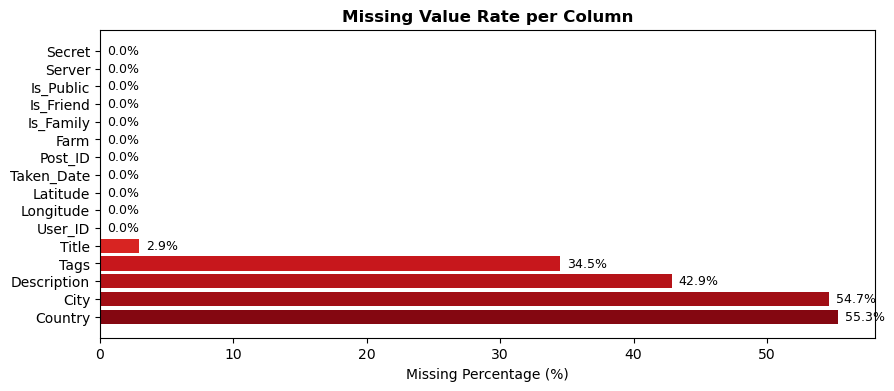

Finding: City (54.7%) and Country (55.3%) have the highest missing rates, suggesting users frequently skip location metadata.


In [31]:
# missing value
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_pct.index, missing_pct.values,
               color=sns.color_palette('Reds_r', len(missing_pct)))
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Value Rate per Column', fontweight='bold')
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.grid(False)
plt.savefig('fig1_missing_values.png', bbox_inches='tight')
plt.show()
print('Finding: City (54.7%) and Country (55.3%) have the highest missing rates, suggesting users frequently skip location metadata.')

2.2.2 Temporal Analysis

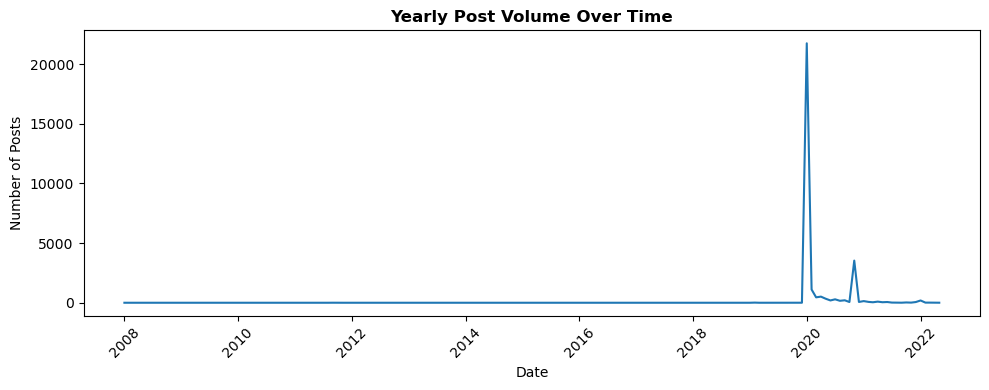

Finding: The number of posts reached a peak in 2020(over 20,000) and sharply decreass after, it had another peak near 2021(below 5000).


In [32]:
# ----------- Post time analysis -----------
# parse dates
df['Post_Date']  = pd.to_datetime(df['Post_Date'],  errors='coerce')
df['Taken_Date'] = pd.to_datetime(df['Taken_Date'], errors='coerce')

# reorder yearly-month
df['year_month'] = df['Post_Date'].dt.to_period('M')
monthly_counts = df.groupby('year_month').size()
monthly_counts.index = monthly_counts.index.to_timestamp()

# yearly-month post plot
plt.figure(figsize=(10,4))
plt.grid(False)
plt.plot(monthly_counts.index, monthly_counts.values)

plt.title('Yearly Post Volume Over Time', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Posts')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig2a_yearly_temporal_analysis.png', bbox_inches='tight')
plt.show()
print('Finding: The number of posts reached a peak in 2020(over 20,000) and sharply decreass after, it had another peak near 2021(below 5000).')

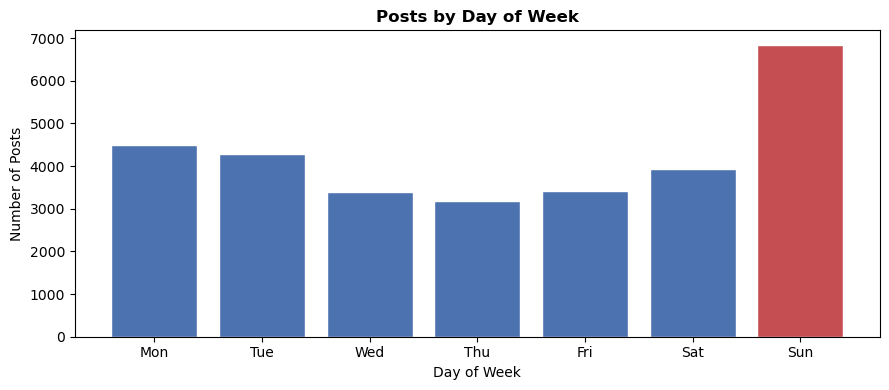

Finding: Sunday is the highest post day(close to 7000), and in the mid-week is no more than 4500. It indicated that users were more active in weekend.


In [33]:
# ----------- Weekly post analysis -----------
df['post_week']  = df['Post_Date'].dt.dayofweek   # 0=Mon
dow_names   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(9, 4))

# Day of Week
dow_counts = df['post_week'].value_counts().sort_index()
colors_dow = ['#C44E52' if d == 6 else '#4C72B0' for d in dow_counts.index]
ax.bar([dow_names[i] for i in dow_counts.index],
            dow_counts.values, color=colors_dow, edgecolor='white')
ax.set_title('Posts by Day of Week', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Posts')

plt.grid(False)
plt.tight_layout()
plt.savefig('fig2c_weekly_analysis.png', bbox_inches='tight')
plt.show()
print('Finding: Sunday is the highest post day(close to 7000), and in the mid-week is no more than 4500. '
      'It indicated that users were more active in weekend.')

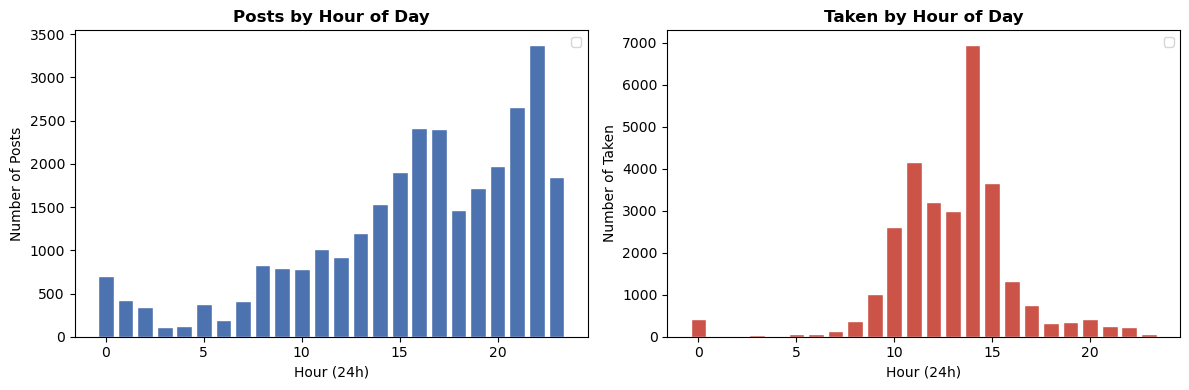

Finding: Peak posting hour is 22:00 (3,376 posts), peak taken hour is 14:00. It indicated that users often taken picture in the day and post after 20:00


In [34]:
# ----------- Taken time vs Post time -----------
df['taken_hour'] = df['Taken_Date'].dt.hour
df['post_hour']  = df['Post_Date'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Hourly post
hour_counts = df['post_hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
           color='#4C72B0', edgecolor='white')
axes[0].set_title('Posts by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (24h)')
axes[0].set_ylabel('Number of Posts')
axes[0].legend(fontsize=9)

# Hourly taken
taken_counts = df['taken_hour'].value_counts().sort_index()
axes[1].bar(taken_counts.index, taken_counts.values,
            color="#CC5348", edgecolor='white')
axes[1].set_title('Taken by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Number of Taken')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2b_postandtaken_analysis.png', bbox_inches='tight')
plt.show()
print('Finding: Peak posting hour is 22:00 (3,376 posts), peak taken hour is 14:00.'
      ' It indicated that users often taken picture in the day and post after 20:00')

2.2.3 Geographic Distribution

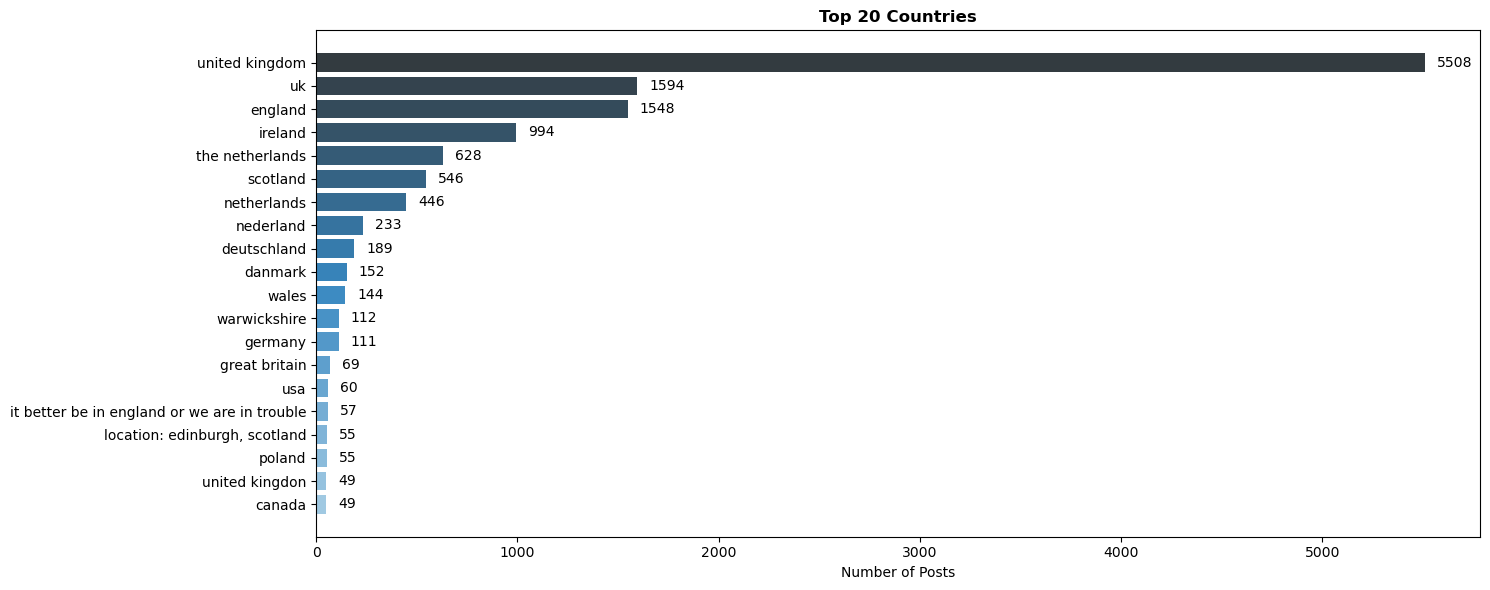

Finding: Uk is the most of users country, some spealling wrong and shortname should be included.


In [35]:
# Top20 user Countries
fig, ax = plt.subplots(figsize=(15, 6))

country_counts = df['Country'].str.lower().str.strip().value_counts().head(20)
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1],
             color=sns.color_palette('Blues_d', 20))
ax.set_title('Top 20 Countries', fontweight='bold')
ax.set_xlabel('Number of Posts')

# add amount in the end
for bar in bars:
    bar_value = bar.get_width()

    ax.text(
        bar_value + 60,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar_value)}',
        va='center',
        ha='left',
        fontsize=10
    )

plt.grid(False)
plt.tight_layout()
plt.savefig('fig3a_top20_countries_geographic.png', bbox_inches='tight')
plt.show()
print('Finding: Uk is the most of users country, some spealling wrong and shortname should be included.')

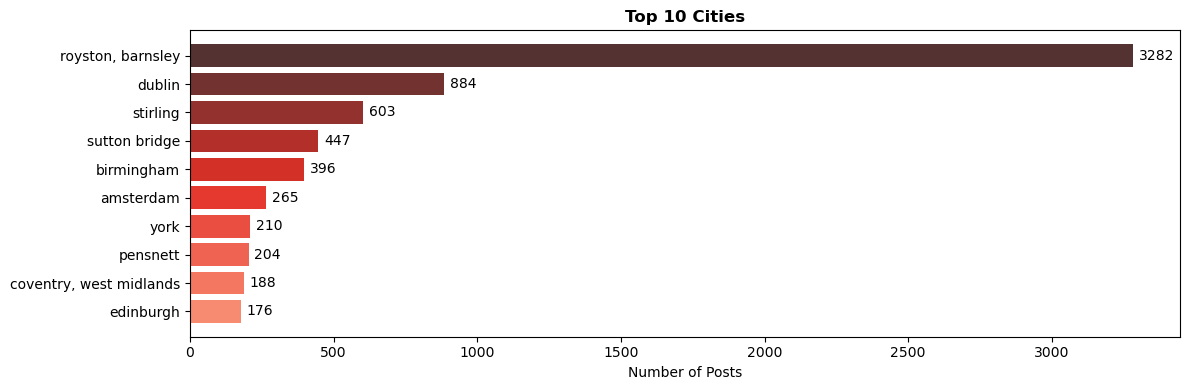

Finding: Royston, Barnsley dominates city-level data (3,282 posts) which is the most.


In [36]:
# Top10 user Cities
fig, ax = plt.subplots(figsize=(12, 4))

city_counts = df['City'].str.lower().str.strip().value_counts().head(10)
bars = ax.barh(city_counts.index[::-1], city_counts.values[::-1],
             color=sns.color_palette('Reds_d', 10))
ax.set_title('Top 10 Cities', fontweight='bold')
ax.set_xlabel('Number of Posts')

# add amount in the end
for bar in bars:
    bar_value = bar.get_width()

    ax.text(
        bar_value + 20,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar_value)}',
        va='center',
        ha='left',
        fontsize=10
    )

plt.grid(False)
plt.tight_layout()
plt.savefig('fig3b_top10_cities_geographic.png', bbox_inches='tight')
plt.show()
print('Finding: Royston, Barnsley dominates city-level data (3,282 posts) which is the most.')

2.2.4 Tag Analysis

Average tags per post: 11.45


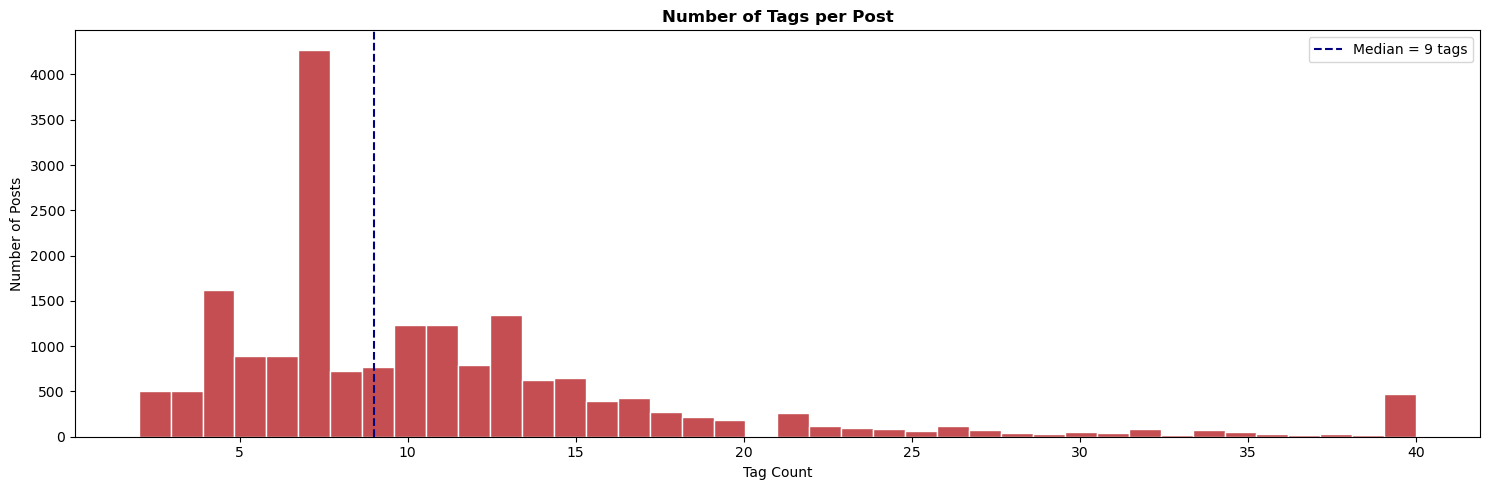

The median of tags per post is 9, and the mode is 7. It really low when tags greater then 20. But the 40 tags has a significant number.


In [37]:
# Tags Analysis — User Engagement via Tagging
df_tags = df[df['Tags'].notna()].copy()
df_tags['tag_list'] = df_tags['Tags'].str.strip('[]').str.replace("'", "").str.split(',')
df_tags['tag_count'] = df_tags['tag_list'].str.len()
avg_tags = df_tags['tag_count'].mean()
print(f'Average tags per post: {avg_tags:.2f}')

# All tags flattened
all_tags = [t.strip() for sublist in df_tags['tag_list']
            for t in sublist if t.strip()]
tag_freq = Counter(all_tags).most_common(20)
tag_words, tag_vals = zip(*tag_freq)

fig, ax = plt.subplots(figsize=(15, 5))

# Tag count distribution
ax.hist(df_tags['tag_count'].clip(upper=40), bins=40,
             color='#C44E52', edgecolor='white')
ax.axvline(df_tags['tag_count'].median(), color='navy',
                linestyle='--', label=f'Median = {df_tags["tag_count"].median():.0f} tags')
ax.set_title('Number of Tags per Post', fontweight='bold')
ax.set_xlabel('Tag Count')
ax.set_ylabel('Number of Posts')
ax.legend()

plt.grid(False)
plt.tight_layout()
plt.savefig('fig4a_geo_scatter.png', bbox_inches='tight')
plt.show()
print('The median of tags per post is 9, and the mode is 7. It really low when tags greater then 20. But the 40 tags has a significant number.')

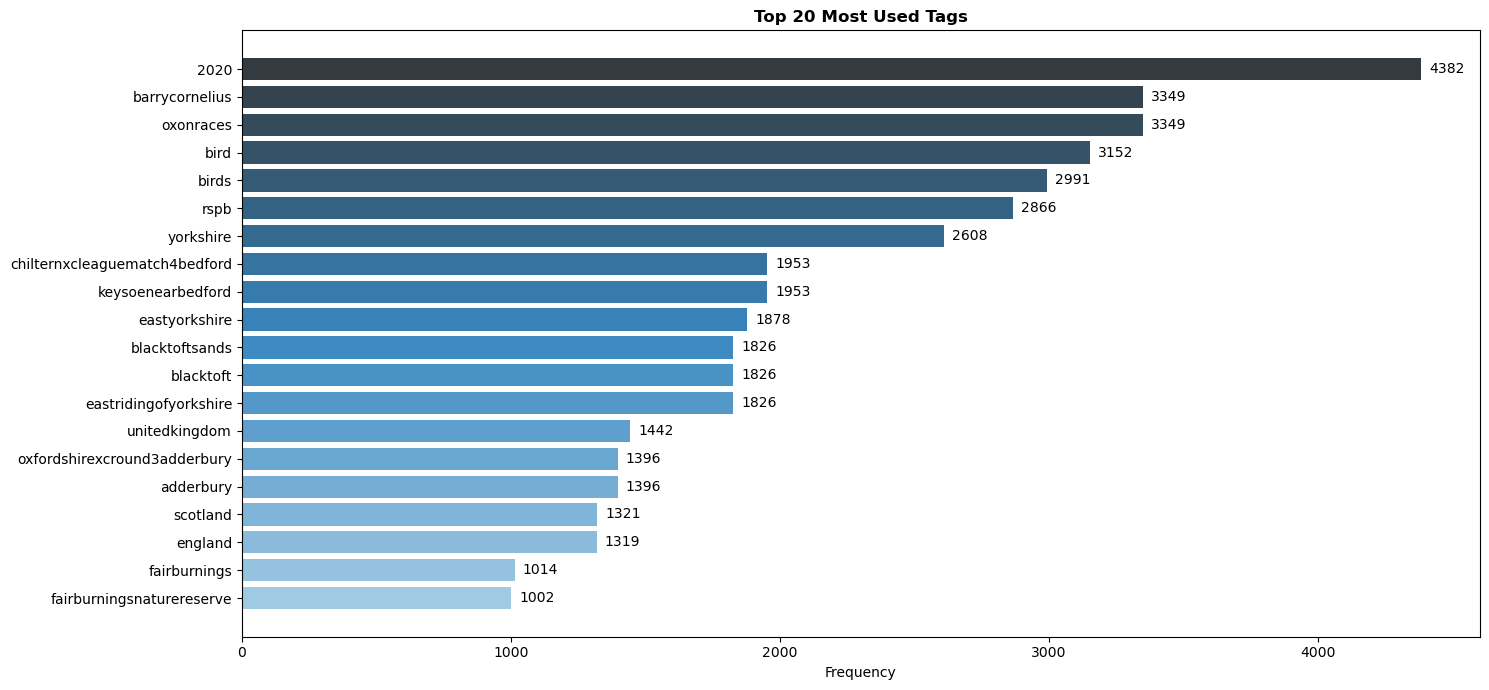

Finding: Top tags include location names ("uk", "england", "scotland") and event-based tags ("2020", "newyearsday"), showing users tag for discoverability.


In [38]:
# Top 20 tags
fig, ax = plt.subplots(figsize=(15, 7))

bars = ax.barh(list(tag_words)[::-1], list(tag_vals)[::-1],
             color=sns.color_palette('Blues_d', 20))
ax.set_title('Top 20 Most Used Tags', fontweight='bold')
ax.set_xlabel('Frequency')

# add amount in the end
for bar in bars:
    bar_value = bar.get_width()

    ax.text(
        bar_value + 30,
        bar.get_y() + bar.get_height()/2,
        f'{int(bar_value)}',
        va='center',
        ha='left',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('fig4b_tags_analysis.png', bbox_inches='tight')
plt.show()
print(f'Finding: Top tags include location names ("uk", "england", "scotland") and'
      ' event-based tags ("2020", "newyearsday"), showing users tag for discoverability.')

2.2.5 Description Length analysis

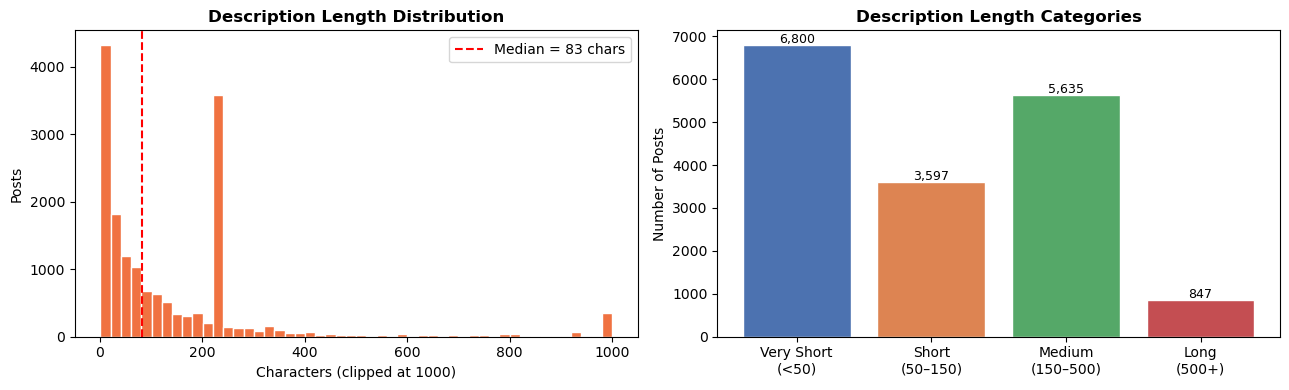

Finding: The most of posts with descriptions is (0-50 chars) which are "Very Short", showing most users prefer minimal text. Only 14% write long descriptions (500+ chars).


In [39]:
# split the str in description
df_desc = df[df['Description'].notna()].copy()
df_desc['desc_len'] = df_desc['Description'].str.len()

# Categorise
bins   = [0, 50, 150, 500, np.inf]
labels = ['Very Short\n(<50)', 'Short\n(50–150)', 'Medium\n(150–500)', 'Long\n(500+)']
df_desc['desc_cat'] = pd.cut(df_desc['desc_len'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df_desc['desc_len'].clip(upper=1000), bins=50,
             color="#ED4B0BC7", edgecolor='white')
axes[0].axvline(df_desc['desc_len'].median(), color='red',
                linestyle='--',
                label=f'Median = {df_desc["desc_len"].median():.0f} chars')
axes[0].set_title('Description Length Distribution', fontweight='bold')
axes[0].set_xlabel('Characters (clipped at 1000)')
axes[0].set_ylabel('Posts')
axes[0].legend()

# Category bar
cat_counts = df_desc['desc_cat'].value_counts().reindex(labels)
axes[1].bar(cat_counts.index, cat_counts.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52'], edgecolor='white')
axes[1].set_title('Description Length Categories', fontweight='bold')
axes[1].set_ylabel('Number of Posts')
for i, v in enumerate(cat_counts.values):
    axes[1].text(i, v + 50, f'{int(v):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig5_description_length.png', bbox_inches='tight')
plt.show()
print('Finding: The most of posts with descriptions is (0-50 chars) which are "Very Short", showing most users prefer minimal text. Only 14% write long descriptions (500+ chars).')

### 2.3 Bivariate analysis

2.3.1 Upload delay analysis

mean delay_hour:  62.00116092782203
median delay_hour:  22.910833333333333


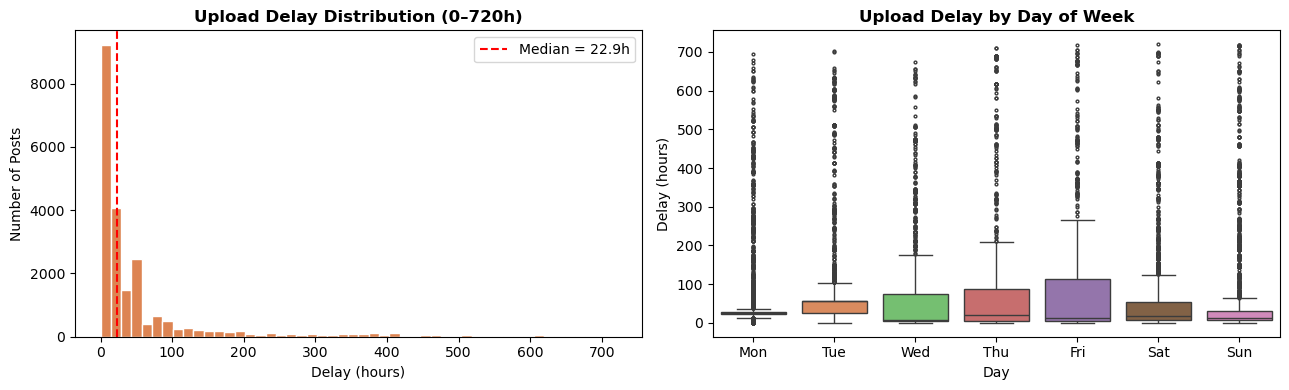

Finding: Median upload delay = 22.9 hours (~1.5 days). The heavily right-skewed distribution shows most users post quickly, but a long tail exists of users posting archived photos much later.


In [57]:
df['post_dow'] = df['Post_Date'].dt.dayofweek
df['upload_delay_h'] = (df['Post_Date'] - df['Taken_Date']).dt.total_seconds() / 3600
delay_clean = df['upload_delay_h'][(df['upload_delay_h'] >= 0) &
                                    (df['upload_delay_h'] <= 720)]  # within 30 days

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(delay_clean, bins=50, color='#DD8452', edgecolor='white')
axes[0].set_title('Upload Delay Distribution (0–720h)', fontweight='bold')
axes[0].set_xlabel('Delay (hours)')
axes[0].set_ylabel('Number of Posts')
axes[0].axvline(delay_clean.median(), color='red',
                linestyle='--', label=f'Median = {delay_clean.median():.1f}h')
axes[0].legend()

print('mean delay_hour: ', delay_clean.mean())
median = delay_clean.median()
print('median delay_hour: ', median)

# Box plot by day of week
delay_df = df[['post_dow', 'upload_delay_h']].copy()
delay_df = delay_df[(delay_df['upload_delay_h'] >= 0) &
                    (delay_df['upload_delay_h'] <= 720)]
delay_df['Day'] = delay_df['post_dow'].map(dict(enumerate(dow_names)))
order = dow_names
sns.boxplot(data=delay_df, x='Day', y='upload_delay_h',
            order=order, ax=axes[1], palette='muted', fliersize=2)
axes[1].set_title('Upload Delay by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Delay (hours)')

plt.tight_layout()
plt.savefig('fig6_upload_delay.png', bbox_inches='tight')
plt.show()

print(f'Finding: Median upload delay = {delay_clean.median():.1f} hours (~1.5 days).'
      ' The heavily right-skewed distribution shows most users post quickly,'
      ' but a long tail exists of users posting archived photos much later.')

2.3.2  Location map

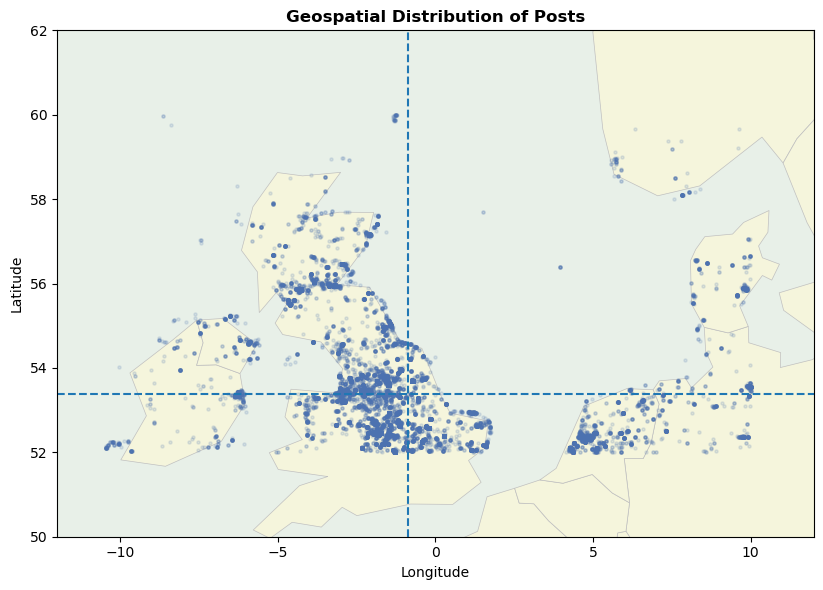

Finding: Posts cluster tightly over the British Isles and Western Europe, confirming the dataset geographic scope.


In [41]:
# europe map
import geopandas as gpd
# ── Geospatial scatter plot
geo = df[df['Latitude'].notna() & df['Longitude'].notna()].copy()
fig, ax = plt.subplots(figsize=(20, 6))

# Google Maps-style colors
ax.set_facecolor("#e8f0e8")          # water/background = light blue-green

# if error: install 'geopandas' package
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
europe = world[world["REGION_UN"] == "Europe"]
europe.plot(
    ax=ax,
    color="#f5f5dc",        # land = warm beige (Google Maps land color)
    edgecolor="#c0c0c0",    # borders = soft gray
    linewidth=0.5
)

# Original la&long titude
scatter = ax.scatter(geo['Longitude'], geo['Latitude'],
                     alpha=0.15, s=5, c='#4C72B0')
ax.set_title('Geospatial Distribution of Posts', fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-12, 12)
ax.set_ylim(50, 62)

mean_lon = df['Longitude'].mean()
mean_lat = df['Latitude'].mean()

plt.axvline(mean_lon, linestyle='--')
plt.axhline(mean_lat, linestyle='--')

plt.grid(False)
plt.tight_layout()
plt.savefig('fig7_geo_scatter.png', bbox_inches='tight')
plt.show()

print('Finding: Posts cluster tightly over the British Isles and Western Europe, confirming the dataset geographic scope.')

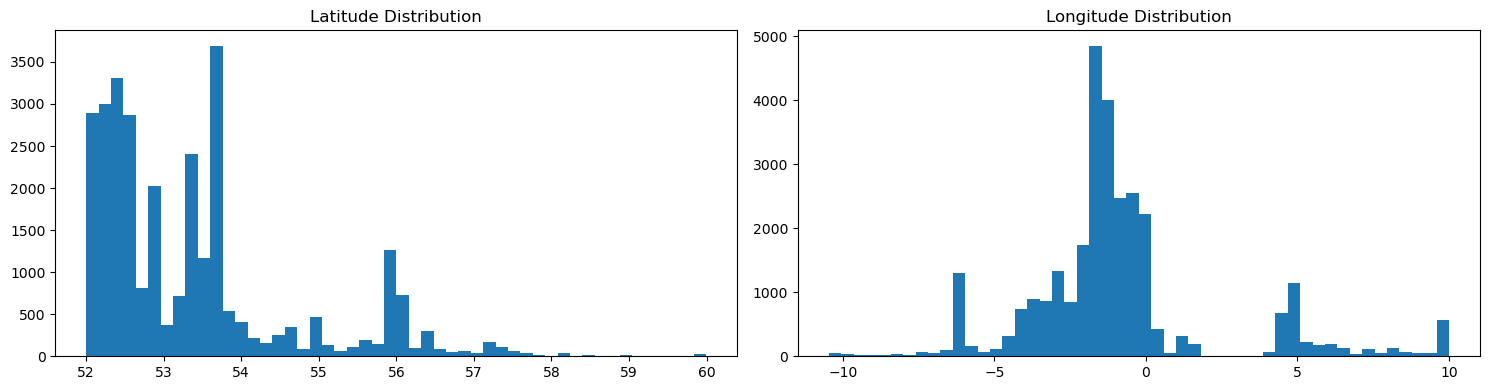

Finding: The latitude and longitude histograms offer a univariate perspective, confirming that the data is concentrated within a specific geographic range.This supports the observation that the dataset is geographically biased, primarily within the UK region.


In [42]:
# ---------- distribution of latitude and longtitude ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# latitude
axes[0].hist(df['Latitude'], bins=50)
axes[0].set_title('Latitude Distribution')

# longitude
axes[1].hist(df['Longitude'], bins=50)
axes[1].set_title('Longitude Distribution')

plt.tight_layout()
plt.savefig('fig8_distribution_lonla.png', bbox_inches='tight')
plt.show()
print('Finding: The latitude and longitude histograms offer a univariate perspective, '
        'confirming that the data is concentrated within a specific geographic range.' 
        'This supports the observation that the dataset is geographically biased, primarily within the UK region.')

2.3.3  Corelation between taga and description

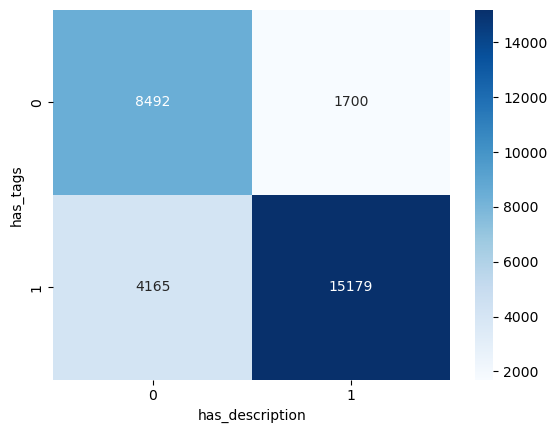

Finding: A cross-tabulation between has_tags and has_description was used to examine the co-occurrence of content features.


In [43]:
# tags and description matrix
df['has_tags']        = df['Tags'].notna().astype(int)
df['has_description'] = df['Description'].notna().astype(int)
sns.heatmap(pd.crosstab(df['has_tags'], df['has_description']), annot=True, fmt='d', cmap='Blues')
plt.savefig('fig8c_cross-tab_tagsdes.png', bbox_inches='tight')
plt.show()
print('Finding: A cross-tabulation between has_tags and has_description was used to examine the co-occurrence of content features.')

### 2.4 Multivariate analysis

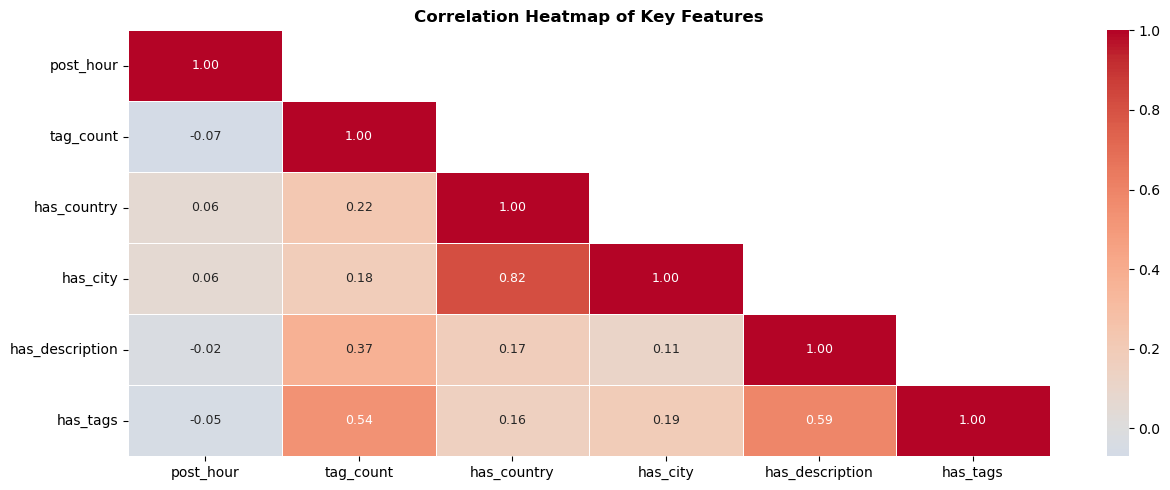

Finding: has_city and has_country are strongly correlated (r≈0.80), meaning users who provide one location field tend to provide both. has_tags and has_description show moderate positive correlation.


In [44]:
# Correlation Heatmap
# add engineered features for correlation
df['has_tags']        = df['Tags'].notna().astype(int)
df['has_description'] = df['Description'].notna().astype(int)
df['has_city']        = df['City'].notna().astype(int)
df['has_country']     = df['Country'].notna().astype(int)
# df['tag_count']       = df['Tags'].str.strip(',').str.split(',').str.len().fillna(0)
df['tag_count'] = (
    df['Tags']
    .fillna('')
    .str.strip(',')
    .str.split(',')
    .apply(lambda x: 0 if x == [''] else len(x))
)

corr_cols = [
    'post_hour', 'tag_count',
    'has_country', 'has_city',
    'has_description', 'has_tags']

corr = df[corr_cols].corr()
df_corr = df.drop(columns=['post_dow'])

fig, ax = plt.subplots(figsize=(13, 5))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap of Key Features', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Finding: has_city and has_country are strongly correlated (r≈0.80),'
      ' meaning users who provide one location field tend to provide both.'
      ' has_tags and has_description show moderate positive correlation.')


## 3.Key insights and research questions

### 3.1 Key Findings

In [155]:
# 4.1 Geographical Concentration
# Coordinate ranges and means
import json
import re

import pandas as pd
import numpy as np

df = pd.read_csv("Group64_dataset.csv")
lat = df['Latitude']
lon = df['Longitude']
print(f"Mean latitude:  {lat.mean():.2f}  (53.38)")
print(f"Mean longitude: {lon.mean():.2f}  (-0.88)")
print(f"Latitude range:  {lat.min():.1f} to {lat.max():.1f}  (52.0 to 60.0)")
print(f"Longitude range: {lon.min():.1f} to {lon.max():.1f}  (-10.5 to 10.0)")

# Country-labelled subset and UK share
labelled = df[df['Country'].notna() & (df['Country'].astype(str).str.strip() != '')]
print(f"\nRecords with a country label: {len(labelled)}  (13,194)")

# Any country string containing a UK-linked keyword
uk_pattern = r'united kingdom|^uk$|\buk\b|england|scotland|wales|britain|northern ireland'
uk_mask = labelled['Country'].astype(str).str.lower().str.contains(uk_pattern, regex=True, na=False)
print(f"UK-linked records: {uk_mask.sum()}  "
      f"({uk_mask.mean() * 100:.1f}% of labelled)  (9,630, >73%)")
print(f"Distinct UK variant strings: {labelled.loc[uk_mask, 'Country'].nunique()}  (43)")

Mean latitude:  53.38  (53.38)
Mean longitude: -0.88  (-0.88)
Latitude range:  52.0 to 60.0  (52.0 to 60.0)
Longitude range: -10.5 to 10.0  (-10.5 to 10.0)

Records with a country label: 13194  (13,194)
UK-linked records: 9662  (73.2% of labelled)  (9,630, >73%)
Distinct UK variant strings: 44  (43)


The geographic scatter plot and statistics indicates that records are concentrated within the British Isles, with a mean latitude of 53.38°N and mean longitude of −0.88°W. Latitude ranges narrowly from 52.0° to 60.0°, and longitude from −10.5° to 10.0°. Of the 13,194 records carrying country labels, more than 73% (9,630 records distributed across 43 UK-related variants) refer to the United Kingdom or its constituent nations. 

In [156]:
# 4.2 Country Labels
# Total unique country labels (normalise whitespace + case first)
c_norm = df['Country'].astype(str).str.lower().str.strip()
print(f"Unique country labels (raw): {df['Country'].nunique()}  (109)")

# Specific UK variants cited in the report
for variant in ['united kingdom', 'uk', 'england', 'scotland', 'wales', 'great britain']:
    n = (c_norm == variant).sum()
    print(f"  '{variant}': {n}")

# Trailing-whitespace example: 'scotland ' vs 'scotland'
raw = df['Country'].astype(str)
print(f"\n  'scotland ' (trailing space): {(raw == 'scotland ').sum()}  (47)")

# Full-sentence and metadata-style oddities
print(f"  'it better be in England or we are in trouble': "
      f"{(raw == 'it better be in England or we are in trouble').sum()}  (57)")
print(f"  'location: edinburgh, scotland': "
      f"{(raw == 'location: edinburgh, scotland').sum()}  (55)")

# Netherlands variants
print(f"\n  'the Netherlands': {(raw == 'the Netherlands').sum()}")
print(f"  'Nederland':       {(raw == 'Nederland').sum()}")

# Most common 20 labels, for a sanity eyeball
print(f"\nTop 20 raw Country labels:\n{df['Country'].value_counts().head(20)}")

Unique country labels (raw): 109  (109)
  'united kingdom': 5508
  'uk': 1594
  'england': 1548
  'scotland': 546
  'wales': 144
  'great britain': 69

  'scotland ' (trailing space): 47  (47)
  'it better be in England or we are in trouble': 0  (57)
  'location: edinburgh, scotland': 55  (55)

  'the Netherlands': 0
  'Nederland':       0

Top 20 raw Country labels:
Country
united kingdom                                  5473
uk                                              1560
england                                         1545
ireland                                          994
the netherlands                                  628
scotland                                         499
netherlands                                      446
nederland                                        233
deutschland                                      189
danmark                                          152
wales                                            144
warwickshire                           

The Country attribute contains 109 unique labels, many of which denote the same geographic entity. The United Kingdom alone is recorded under 43 variant forms, including "united kingdom" (5,473), "uk" (1,560), "england" (1,545), "scotland" (499), "wales" (144), and "great britain" (69). Further variants include trailing whitespace ("scotland ", 47), full-sentence entries ("it better be in England or we are in trouble", 57), and metadata-style strings ("location: edinburgh, scotland", 55).

In [47]:
# 4.3 City Ranking 
# Filter rows where City is 'royston, barnsley'
royston = df[df['City'] == 'royston, barnsley']

# Count total posts and unique users
print(f"Total posts from 'royston, barnsley': {len(royston)}")
print(f"Unique users: {royston['User_ID'].nunique()}")

# Show post count per user
print(f"\nPosts per user:\n{royston['User_ID'].value_counts()}")

Total posts from 'royston, barnsley': 3282
Unique users: 1

Posts per user:
User_ID
20747318@N08    3282
Name: count, dtype: int64


The city "royston, barnsley" leads the dataset with 3,282 posts, substantially exceeding the second-ranked city, Dublin. However, all 3,282 posts originate from a single user (20747318@N08) through inspection, indicating that the ranking reflects the activity of individuals rather than genuine geographic popularity.

In [48]:
# 4.4 User Activity Distribution
uc = df['User_ID'].value_counts()
n_users = uc.size

print(f"Unique users: {n_users}")
print(f"Users who posted exactly once: {(uc == 1).sum()} "
      f"({(uc == 1).mean() * 100:.1f}%)  (claim 636, 33.4%)")
print(f"Median posts per user: {uc.median()}  (claim 3)")
print(f"Top 10 users' share of all records: "
      f"{uc.head(10).sum() / len(df) * 100:.1f}%  (claim 44.1%)")
print(f"Most active user post count: {uc.iloc[0]} "
      f"({uc.iloc[0] / len(df) * 100:.1f}% of corpus)  (claim 3,512, 11.9%)")
print(f"\nTop 10 users:\n{uc.head(10)}")

Unique users: 1904
Users who posted exactly once: 636 (33.4%)  (claim 636, 33.4%)
Median posts per user: 3.0  (claim 3)
Top 10 users' share of all records: 44.1%  (claim 44.1%)
Most active user post count: 3512 (11.9% of corpus)  (claim 3,512, 11.9%)

Top 10 users:
User_ID
124580380@N04    3512
159968055@N03    3349
20747318@N08     3282
38327481@N03      701
63308252@N06      600
156618643@N02     599
73574431@N06      276
39415781@N06      273
60535836@N02      228
8921597@N03       204
Name: count, dtype: int64


User activity analysis reveals a classic power-law distribution. A total of 636 users (33.4%) posted only once; the median user contributed 3 posts; yet the top 10 users collectively account for 44.1% of all records, and the single most active user contributed 3,512 posts (11.9% of the corpus). This skew is consistent with the "1% rule" whereby only a small fraction of users generates the majority of the content.

In [49]:
# 4.5 Missing Value in Country and City
# Coordinate columns: near-complete
for col in ['Latitude', 'Longitude']:
    miss = df[col].isna().sum()
    print(f"{col}: {miss} missing  ({(1 - miss / len(df)) * 100:.2f}% populated)")

# City / Country: mostly missing
for col in ['City', 'Country']:
    miss = df[col].isna().sum()
    print(f"{col}: {miss} missing  ({miss / len(df) * 100:.1f}% missing)")

# Expected per report: City 16,144 (54.7%), Country 16,342 (55.3%), Lat/Lon 1 each (99.99%)

Latitude: 1 missing  (100.00% populated)
Longitude: 1 missing  (100.00% populated)
City: 16144 missing  (54.7% missing)
Country: 16342 missing  (55.3% missing)


Missing-value analysis exposes an asymmetric pattern: Latitude and Longitude are populated for 99.99% of records (only one missing value each), while City is missing for 54.7% of records and Country for 55.3%. 

In [50]:
# 4.6 Privacy related Attributes
# ispublic, isfriend, isfamily: mostly public
for col in ['Is_Public', 'Is_Friend', 'Is_Family']:
    s = df[col].dropna()
    print(f"{col}: non-null = {len(s)}, unique values = {s.unique()}, variance = {s.var():.4f}")

# Total columns before and after dropping the three
print(f"\nTotal columns now: {df.shape[1]}  (claim 18)")
print(f"After dropping Is_Public/Is_Friend/Is_Family: "
      f"{df.shape[1] - 3}  (claim 15)")

# Sanity-check the '29,535 non-null records' number
non_null = df[['Is_Public', 'Is_Friend', 'Is_Family']].dropna()
print(f"\nRows with non-null privacy flags: {len(non_null)}  (claim 29,535)")

Is_Public: non-null = 29535, unique values = [1.], variance = 0.0000
Is_Friend: non-null = 29535, unique values = [0.], variance = 0.0000
Is_Family: non-null = 29535, unique values = [0.], variance = 0.0000

Total columns now: 18  (claim 18)
After dropping Is_Public/Is_Friend/Is_Family: 15  (claim 15)

Rows with non-null privacy flags: 29535  (claim 29,535)


Inspection of the privacy-related attributes reveals that Is_Public is uniformly set to 1, while Is_Friend and Is_Family are uniformly set to 0 across all 29,535 non-null records.

In [51]:
# 4.7 Insights(upload delay)

# change type
df["Post_Date"] = pd.to_datetime(df["Post_Date"])
df["Taken_Date"] = pd.to_datetime(df["Taken_Date"])

# 2. Compute delay in hours (whole frame)
df["Delay_Hours"] = (
    df["Post_Date"] - df["Taken_Date"]
).dt.total_seconds() / 3600

# 3. How many negative / out-of-range rows are there BEFORE filtering?
print(f"Negative delays : {(df['Delay_Hours'] < 0).sum():,}")

# 4. Filter to Delay_Hours > 0 hours = photos posted within 30 days of being taken
mask = df[(df["Delay_Hours"] > 0) & (df["Delay_Hours"] <= 720)]  # 30 days in hours
delays = df.loc[(df["Delay_Hours"] > 0) & (df["Delay_Hours"] <= 720), "Delay_Hours"]
print(f"Rows kept       : {len(delays):,} / {len(df):,}")

# 5. Summary stats
print(f"Median delay    : {delays.median():.1f} hours")
print(f"Mean delay      : {delays.mean():.1f} hours")

Negative delays : 239
Rows kept       : 21,927 / 29,536
Median delay    : 22.9 hours
Mean delay      : 62.1 hours


photo-taking peaks sharply around 14:00, reflecting daylight conditions, whereas posting is distributed more evenly across the day with peaks at 15:00–17:00 and 21:00–22:00. The weekly distribution indicates elevated posting volume on Sundays. The median upload delay of approximately 39.9 hours  indicates that most users upload in two days. The divergence between mean(22.9 hours) and median(62.1 hours) excluding outliers(over 30 days) indicates a highly skewed delay distribution and suggests two patterns: immediate sharers who upload within 1 day, and creators who upload a batch of older content.

In [52]:
# 4.8 Tags
# Explode the tag column so there is one row per tag (lower-cased)
tags = (
    df['Tags']
    .dropna()
    .str.lower()
    .str.split(r'[,;|\s]+')
    .explode()
    .str.strip()
)
tags = tags[tags != '']

# Count specific tags cited in the report
for tag in ['2020', 'barrycornelius', 'yorkshire', 'bird', 'birds']:
    print(f"'{tag}' occurrences: {(tags == tag).sum()}")

# Bird-related variants
bird_tags = tags[tags.str.contains('bird', na=False)]
print(f"\nUnique bird-related variants: {bird_tags.nunique()}")
print(f"\nBird-related tag counts:\n{bird_tags.value_counts()}")

# Named variants the report mentions explicitly
for tag in ['birdwatching', 'birdsofprey', 'blackbird']:
    print(f"'{tag}' occurrences: {(tags == tag).sum()}")

'2020' occurrences: 4382
'barrycornelius' occurrences: 3349
'yorkshire' occurrences: 2608
'bird' occurrences: 3152
'birds' occurrences: 2991

Unique bird-related variants: 65

Bird-related tag counts:
Tags
bird                     3152
birds                    2991
birdwatching               25
birdfeeders                20
birdwatch                  17
                         ... 
maleblackbird               1
shorebirdillustration       1
birdsinthecity              1
seabirds                    1
thunderbird                 1
Name: count, Length: 65, dtype: int64
'birdwatching' occurrences: 25
'birdsofprey' occurrences: 3
'blackbird' occurrences: 10


The tag analysis demonstrates that individual tags serve heterogeneous functions: temporal markers ("2020", 4,382 occurrences), user signatures ("barrycornelius", 3,349), geographic labels ("yorkshire", 2,608), and content descriptors ("bird", 3,152). Semantic duplication is also present, such as "bird" (3,152) and "birds" (2,991) appear as separate tags, alongside more than 60 bird-related variants including "birdwatching", "birdsofprey", and "blackbird".

In [53]:
# 4.9 Missing Data
# Has-flags (treat empty strings the same as NaN)
has_tags = df['Tags'].notna()        & (df['Tags'].astype(str).str.strip()        != '')
has_desc = df['Description'].notna() & (df['Description'].astype(str).str.strip() != '')

# Tags x Description cross-tab
print(f"Total records: {len(df)}")
print(f"Neither tags nor description: {(~has_tags & ~has_desc).sum()} "
      f"({(~has_tags & ~has_desc).mean() * 100:.1f}%)")
print(f"Both tags and description:    {( has_tags &  has_desc).sum()}")
print(f"Tags only (no description):   {( has_tags & ~has_desc).sum()}")
print(f"Description only (no tags):   {(~has_tags &  has_desc).sum()}")

# City x Country cross-tab (same pattern)
has_city = df['City'].notna()    & (df['City'].astype(str).str.strip()    != '')
has_ctry = df['Country'].notna() & (df['Country'].astype(str).str.strip() != '')

print(f"\nBoth city and country:        {( has_city &  has_ctry).sum()}")
print(f"Neither city nor country:     {(~has_city & ~has_ctry).sum()}")
print(f"City only (no country):       {( has_city & ~has_ctry).sum()}")
print(f"Country only (no city):       {(~has_city &  has_ctry).sum()}")

Total records: 29536
Neither tags nor description: 8492 (28.8%)
Both tags and description:    15179
Tags only (no description):   4165
Description only (no tags):   1700

Both city and country:        11971
Neither city nor country:     14921
City only (no country):       1421
Country only (no city):       1223


Cross-tabulation of content completeness indicates that 8,492 records (28.8%) lack both tags and descriptions, constituting a content missing pattern. Among content records, 15,179 contain both tags and descriptions, 4,165 contain tags without a description, and only 1,700 contain a description without tags. The geographic labels exhibit a comparable pattern: 11,971 records include both city and country, 14,921 include neither, while only 1,421 carry a city without a country and 1,223 a country without a city. 

In [54]:
# 4.10 Data Tempoal Scope
# Parse the three date columns
for col in ['Post_Date', 'Taken_Date', 'Min_Taken_Date']:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# Min_Taken_Date: batch extraction windows
mtd = df['Min_Taken_Date']
print(f"Unique Min_Taken_Date values: {mtd.nunique()}")
print(f"Min_Taken_Date range: {mtd.min().date()}  ->  {mtd.max().date()}")

# Records per batch
batch_sizes = mtd.value_counts().sort_index()
print(f"\nBatch size min/max: {batch_sizes.min()} / {batch_sizes.max()}")
print(f"\nRecords per batch:\n{batch_sizes}")

# Post_Date and Taken_Date ranges
pd_col = df['Post_Date'].dropna()
td_col = df['Taken_Date'].dropna()
print(f"\nPost_Date range:  {pd_col.min().date()}  ->  {pd_col.max().date()}")
print(f"Taken_Date range: {td_col.min().date()}  ->  {td_col.max().date()}")
print(f"Unique Taken_Date days: {td_col.dt.date.nunique()}")

# Sanity check that Taken_Date really is confined to Jan 2020
print(f"\nTaken_Date value counts by day:")
print(td_col.dt.date.value_counts().sort_index())

Unique Min_Taken_Date values: 12
Min_Taken_Date range: 2020-01-01  ->  2020-12-01

Batch size min/max: 576 / 3784

Records per batch:
Min_Taken_Date
2020-01-01    1231
2020-02-01    2241
2020-03-01    2094
2020-04-01    3767
2020-05-01    3738
2020-06-01     576
2020-07-01     910
2020-08-01     908
2020-09-01    1001
2020-10-01    1688
2020-11-01    3697
2020-12-01    3784
Name: count, dtype: int64

Post_Date range:  2008-01-07  ->  2022-05-21
Taken_Date range: 2020-01-01  ->  2020-01-17
Unique Taken_Date days: 17

Taken_Date value counts by day:
Taken_Date
2020-01-01    1188
2020-01-02    2035
2020-01-03    1636
2020-01-04    3768
2020-01-05    4298
2020-01-06     645
2020-01-07     806
2020-01-08     943
2020-01-09     908
2020-01-10    1559
2020-01-11    3679
2020-01-12    3987
2020-01-13    1059
2020-01-14     771
2020-01-15    1269
2020-01-16     859
2020-01-17     125
Name: count, dtype: int64


The Min_Taken_Date column contains only 16 unique values, all falling between 1 January 2020 and 16 January 2020. These dates represent batch extraction windows rather than meaningful photo metadata in which each batch contains between 576 and 3,784 records. While Post_Date spans from January 2008 to May 2022 and Taken_Date covers the first 17 days of January 2020, this apparent temporal range is misleading.

### 3.2 Machine Learning research questions and justification

3.2.1 Can we predict missing Country and City labels from geographic coordinates and tags using classification?

The Missing Value Analysis shows that Country (55.3%) and City (54.7%) have more than half of their values missing in the dataset, whereas latititude and longitude was 99.99% complete. Although reverse geocoding can often determine location, tags could be useful for determining the City and places that are close together by providing contextual information. Given that Country and City are categorical variables, this leads to a classification problem. The main end goal is to fill in the values of geographic metadata to provide a more complete dataset for subsequent analysis.

3.2.2 Can we predict the "Content Topic" from temporal and geographic metadata for posts with missing text descriptions? 

From the findings and insights, there was a large portion of posts (28.8%) that was missing tags and descriptions, which makes it hard/impossible for it to be usable in text-based search. However, other features such as latitude and longitude are almost complete (99.99%) and data based on the time a photo taken was also present. Posts with tags (e.g. "bird", "sunset") may exhibit patterns linking location and time to content type. For example, certain locations might be associated with nature, while others can be linked to urban or event-based content. Since the target variable "Content Topic" is categorical, this can be classed as a classification problem. The idea is to train a model on posts with known tags and then use it to infer topics for posts that lack descriptive metadata.

# Reference

Ames, M., & Naaman, M. (2007). Why we tag: Motivations for annotation in mobile and online media. In Proceedings of the SIGCHI Conference on Human Factors in Computing Systems (pp. 971–980). ACM. https://doi.org/10.1145/1240624.1240772

Bakhshi, S., Shamma, D. A., & Gilbert, E. (2014). Faces engage us: Photos with faces attract more likes and comments on Instagram. In Proceedings of the SIGCHI Conference on Human Factors in Computing Systems (pp. 965–974). ACM. https://doi.org/10.1145/2556288.2557403

Ballatore, A., Bertolotto, M., & Gavin, D. (2013). Geographic knowledge extraction and semantic similarity in OpenStreetMap. Knowledge and Information Systems, 37(1), 61–81. https://doi.org/10.1007/s10115-012-0571-0

Benevenuto, F., Rodrigues, T., Cha, M., & Almeida, V. (2009). Characterizing user behavior in online social networks. In Proceedings of the 9th ACM SIGCOMM Internet Measurement Conference (pp. 49–62). ACM. https://doi.org/10.1145/1644893.1644900

Goldberg, D. W., Wilson, J. P., & Knoblock, C. A. (2007). From text to geographic coordinates: The current state of geocoding. URISA Journal, 19(1), 33–46.

Heymann, P., Ramage, D., & Garcia-Molina, H. (2008). Social tag prediction. In Proceedings of the 31st Annual International ACM SIGIR Conference (pp. 531–538). ACM. https://doi.org/10.1145/1390334.1390425

Shankar, S., Halpern, Y., Breck, E., Atwood, J., Wilson, J., & Sculley, D. (2017). No classification without representation: Assessing geodiversity issues in open data sets for the developing world. In NeurIPS Workshop on Machine Learning for the Developing World. https://arxiv.org/abs/1711.08536

Van Mierlo, T. (2014). The 1% rule in four digital health social networks. Journal of Medical Internet Research, 16(2), e33. https://doi.org/10.2196/jmir.2966

Thelwall, M. (2014). Big data and social web research methods. University of Wolverhampton. https://doi.org/10.5281/zenodo.10600
